# Indigenous Food Sovereignty: Analyzing Crop Diversity & Food Access in the US

In this Python notebook, students will get an opportunity to work with data about crop diversity & Native food access through hands-on visualizations!

The code below imports all necessary libraries for the code to run. If you don't understanding the terminology, that's okay! Students are not expected to have any coding experience to learn from this Python notebook, though for those who understand the code, it's a bonus.

Simply press the triangle to the left on the cell that appears in the square brackets [ ] or hit shift + enter.

In [ ]:
!pip install folium
!pip install branca
!pip install geopandas
!pip install plotly

In [ ]:
# Standard data science libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Imports for interactive visualizations.
import os
import folium
import json
import branca.colormap as cm
import geopandas as gpd
from branca.colormap import linear
from folium.plugins import TimeSliderChoropleth
from datetime import datetime
import plotly.express as px
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon

In [ ]:
# Initialization cells--just run these! Don't worry if it takes a while.

aiannh_geo = gpd.read_file('tl_2020_us_aiannh.json')
county_codes = pd.read_csv('county-codes.csv', sep=";")
farm_regions = pd.read_excel('counties-to-farm-regions.xlsx')

aiannh_geo['AIANNHCE'] = aiannh_geo['AIANNHCE'].astype(int)
with open('crop-diversity-index-2012-2022-new.xlsx','rb') as f:
  crop_diversity = pd.read_excel(f)

cd = crop_diversity.rename({"Simpson's Index of Diversity":"diversity_index"},axis=1)
years = cd['Date'].unique()
census_codes = cd['AIANNHCE'].unique()

pst_utc_offset = 28800
yrs_s = [int(datetime.strptime(str(yr), "%Y").timestamp()) + pst_utc_offset for yr in years]
yr_conv = dict(zip(years.tolist(),yrs_s))
yrs_s

cd['yrs_in_s'] = cd['Date'].map(yr_conv)
cd.dropna(axis=0,inplace=True)

styledata = {}
min_c, max_c = 0, 1
opacity = 1
cmap = linear.RdYlGn_04.scale(min_c, max_c)
cd['color'] = cd['diversity_index'].apply(cmap)

styledata = {int(key): None for key in census_codes}
for c in styledata.keys():
  styledata[c] = {key: None for key in yrs_s}

for code in census_codes:
  for yr in yrs_s:
    color = '#d7191cff'
    if len(cd[(cd['AIANNHCE']==code) & (cd['yrs_in_s']==yr)]['color'].values) != 0:
      color = cd[(cd['AIANNHCE']==code) & (cd['yrs_in_s']==yr)]['color'].values[0]
    styledata[code][yr] = {'color': color, 'opacity': 1}

counties = gpd.read_file('counties.geojson')
counties['coty_fp_code'] = counties['coty_fp_code'].astype(int)
counties['county_code'] = county_codes['Official Code County']
counties_region = counties.merge(farm_regions,left_on='county_code',right_on='Fips', how='left')
counties_region.dropna(axis=0,inplace=True)
regions = counties_region[['geometry','ERS resource region']]
regions = regions.dissolve(by='ERS resource region')
regions = regions.rename({1:'region'},axis=1)
regions.reset_index(inplace=True)
regions['name'] = ['Heartland','Northern Crescent','Northern Great Plains','Prairie Gateway','Eastern Uplands','Southern Seaboard','Fruitful Rim','Basin and Range','Mississippi Portal']

step = cm.linear.Set1_06.to_step(9).scale(1,9)
aiannh_plus_regions = []
aiannh_regions_names = []

for i in np.arange(len(aiannh_geo)):
  #closest_region = 0
  pt = Point(aiannh_geo.loc[i,'INTPTLAT'], aiannh_geo.loc[i,'INTPTLON'])
  poly = aiannh_geo.loc[i,'geometry']
  for j in np.arange(len(regions)):
    if pt.within(regions.loc[j,'geometry']):
      aiannh_plus_regions.append(regions.loc[j,'ERS resource region'])
      aiannh_regions_names.append(regions.loc[j, 'name'])
      break
    if poly.intersects(regions.loc[j,'geometry']):
      aiannh_plus_regions.append(regions.loc[j,'ERS resource region'])
      aiannh_regions_names.append(regions.loc[j, 'name'])
      break
    if poly.dwithin(regions.loc[j,'geometry'],.5 ):
      aiannh_plus_regions.append(regions.loc[j,'ERS resource region'])
      aiannh_regions_names.append(regions.loc[j, 'name'])
      break
  if len(aiannh_plus_regions) < i+1:
    aiannh_plus_regions.append(0)
    aiannh_regions_names.append('N/A')

aiannh_geo['region'] = aiannh_plus_regions
aiannh_geo['region_name'] = aiannh_regions_names
merged = pd.merge(cd, aiannh_geo[['AIANNHCE','region','region_name']], on='AIANNHCE')



DataSourceError: tl_2020_us_aiannh.json: No such file or directory

# 1. What is a Jupyter Notebook?

A Jupyter Notebook is a coding environment which allows you to include writing, diagrams, visualizations, and videos alongside your code. For these reasons, Jupyter Notebooks are the go-to for many disciplines, including data scientists.

**What is a Cell?**

The rectangular blocks which make up the notebook are called cells. If a cell contains code it is called a code cell, and if it contains plain text it is called a markdown cell.

**How do I Run a Cell?**

To run a code cell, select it, then press either:
* CONTROL + ENTER
* SHIFT + ENTER
* The run button at the top of the screen

**What Happens After I Run a Cell?**

Running a markdown cell, that's the one with plain text, will simply render the text visible to you. Whereas running a code cell may create an output. This output may be text, a visualization, or nothing. It all depends on the code.

In [ ]:
# Run this code cell with one of the above methods.
print("Hello World")

Hello World


Here, the output is a some printed text. You can also output numbers, and as you will see later, graphs and visualizations.

In [ ]:
# Run this code cell with one of the above methods.
2000 + 25

2025

The words following a # become a comment. A comment is text that the computer will ignore when running code. Comments are used to leave helpful notes to yourself and others who will read your code.

# 2. What is Food Sovereignty?

Across the globe, Indigenous communities are reclaiming the right to grow, gather, and share the foods their ancestors relied on. But these movements are about tackling more than just hunger. They confront the losses colonization has caused to Indigenous culture, health, and self-determination.

**What Makes a Food Sovereignty Movement?**

Food sovereignty movements have big goals, so participants view food sovereignty as point on the horizon to aim for, or a method to reach these goals. Food sovereignty can be about how food is obtained, how people live, and how to decolonize all at once. While food sovereignty movements are as varied as the communities they come from, there are four key principles that guide Indigenous food sovereignty (IFS) movements.

1.   Sacred obligation to maintain reciprocal ties with land, plants, and animals.
2.   Cultural continuity through harvesting, preparation, and ceremony.
3.   Community autonomy in deciding what is grown, gathered, and eaten.
4.   Political engagement to align settler laws with Indigenous values.

Because colonial disruption of Indigenous ways of life unfolded over centuries, reclaiming food systems will, by necessity, be multi‑generational. As you will explore in this notebook, Indigenous organizers and activists today are making real change that continues the work of those who came before them.

**Why The Focus on Food?**

Food is at the intersection of health, culture, land, and independence. Food is central to the continued well-being of communities. Its vital importance to life means that food can be–and was–used as a weapon. Indigenous peoples in North America have a recent collective memory of having their land stolen, before being forced by the government off of their ancestral diets and onto rations. Indigenous families were also compelled by the threat of violence to send their children to boarding schools. These schools tried to make Indigenous children forget, or abandon their way of life with strict rules against cultural expression and harsh punishments for not obeying. The nutritional quality of these rations and boarding school diets were low. They also did not include Indigenous cultural foods. Food sovereignty activists today draw a direct line from forced rations and boarding school diets to their communities’ food insecurity and struggle for political self-determination today.

**What Makes Food Sovereignty Important Today?**

While many reservations have grocery stores, many of these stores don’t carry fresh foods, or when they do, these foods are not affordable to most within the community. These stores often funnel money off the reservation. As much as a quarter of every dollar spent on a reservation may leave the community to buy food. Growing even a fraction of a community’s diet locally keeps wealth circulating among tribal farmers, markets, and restaurants. More importantly, it reduces dependence on external corporations. Self-sufficiency with food, contributes to self-sufficiency economically and politically.

**What is the Spiritual Significance of Food?**

In the Diné (Navajo) story of creation, corn and the first human come into being side by side ([If you're curious you can read more about it here](https://navajopeople.org/blog/navajo-creation-story-the-first-world-nihodilhil-black-world/)). This story is one example, but many Indigenous cultures believe that food is a divine gift, because food is more than just something to eat. Planting, harvesting, and cooking are often done in community with others. These group activities form special traditions amongst various cultures. In these cultures, food and the lands it comes from are treated like family, family that makes life possible, thus we are to treat them with respect and care.


# 3. Crop Diversity & Monoculture

In "[Seed Savers Regrow Legacies](https://www.americanindianmagazine.org/Indigenous-seed-savers)", we discuss the cultural importance of saving and growing heirloom species to Native communities. Native cultivators report a sense of spiritual satisfaction from collecting a wide variety of seeds and bringing them back into the food system. However this practice, called **polyculture**, is counter to modern trends in agriculture which tend to favor the opposite, called **monoculture**.

**Monoculture** is when only one type of crop is grown on an area of land. Relatedly mono**cropping** is when this crop is regrown every year. When you drive past farms with endless fields of corn, this is what you're seeing, and it is reflected in the food that we eat.

### Reflection: Think back to your last trip to the grocery store. How many varieties of corn do you remember seeing? What kind of corn is it?

***Your answer here***

If you're like most Americans, you're likely only seeing 2 or 3 varieties of fresh corn and likely they are all labeled by their color: white, yellow, or multi-colored. Despite this, there are hundreds of varieties of corn that are native to North America. With the advent of genetically modified crops, it became easier for farmers to take only a few varieties of corn and grow them to guarantee yields without worrying about the threat of pests. Government subsidies and the consolidation of agribusiness vendors also encouraged this practice of monocropping. However this practice has many disadvantages. Studies show that monocultures are much less resistant to pests and disease, as nature adapts around human-guided resistance, causing farmers to rely more on synthetic pesticides that can damage the environment. This means that in a food system heavily reliant on a few crops, the chance for massive disruption is very high. Monoculture can also reduce biodiversity in their environments and lead to unhealthier soil. And yet, [studies](https://www.researchgate.net/publication/281552541_Crop_Species_Diversity_Changes_in_the_United_States_1978-2012) show that crop diversity has only decreased in recent years.

For more information on monoculture farming, read this [article](https://sentientmedia.org/monoculture/).

Meanwhile, as you can see in the "Seed Savers" article, polyculture is a core part of Indigenous farming practices. Indigenous people have always been at the forefront for sustainable farming, but in recent years, their work has been increasingly recognized by non-Natives for its benefits to the health of our food systems and to the land and climate as a whole.  

Now load the following map with shift + enter. If it takes a while, don't worry! This is perfectly normal.

In [ ]:
#from folium.plugins import GroupedLayerControl

us_center = (37.58, -100.46)
m = folium.Map(us_center, zoom_start=4)
tile_layer = 'https://tiles.stadiamaps.com/tiles/stamen_terrain_background/{z}/{x}/{y}{r}.{ext}'
tooltip = folium.GeoJsonTooltip(
    fields=["name"],
    aliases=['Region Name']
)

farm_region = folium.GeoJson(
    regions,
    style_function = lambda feature:{
        'fillColor':step(feature['properties']['ERS resource region']),
        'color':'black',
        'weight':0.5
    },
    highlight_function=lambda feature: {
        "fillColor": "white"
    },
    tooltip=tooltip,
    name='Farm Regions',
    show=False,
    overlay=True

)
farm_region.add_to(m)

choro = TimeSliderChoropleth(
    aiannh_geo.set_index('AIANNHCE').to_json(),
    styledict= styledata,
    date_options= "YYYY",
    name='Crop Diversity',
    show=True
)
choro.add_to(m)
cmap.caption = "Simpson's Index of Diversity"
cmap.add_to(m)

native_lands = folium.GeoJson(
    aiannh_geo,
    style_function=lambda feature: {
        'fillColor': None,
        'color': 'black',
        'weight': 1
        },
    tooltip=folium.GeoJsonTooltip(
        fields=["NAMELSAD", "region_name"],
        aliases=['Name', 'Approximate Region']
    ),
    highlight_function=lambda feature: {
        "fillColor": "white"
    },
    name='Native Lands',
    show=True

)
native_lands.add_to(m)
folium.LayerControl(collapsed=False, autoZIndex=True).add_to(m)

m

NameError: name 'folium' is not defined

This map is called a **choropleth**. Choropleths shade in chosen regions on a map according to some statistical measure. In this case, we have shaded in tribal lands as recognized and defined by the National Congress of American Indians, based on an estimate of crop diversity, with 0 being no diversity and 1 being infinite diversity.

Feel free to interact with this map by using the time slider, panning around, zooming in, and adding/removing layers.

### Question: What are some things you notice? Is there anything missing?</div>

***Your answer here***

You may have noticed that tribal groups in your area are not represented on this map. You may have also noticed the sparsity of Native lands across the United States. This speaks to the history of settler-colonialism and genocide against Indigenous people. To this day, many Native tribes still fight for recognition by the United States government.

You may have also noticed areas that jump back and forth from being deep red to another color. This is because we have filled in unavailable data with an index of 0. It is important to consider our data, how it was collected, how it was cleaned, and how it is being presented to us.

### What are some possible side-effects of our filling missing values in with 0? How would this be different if we filled these values in with 1 or if we simply left them out?

***Your answer here***

Lastly, you may have noticed that there is a positive trend in diversity in tribal lands. Let's confirm this hunch by running the next cell. Keep in mind that this data is limited--it spans only from 2012 to 2022.

In [ ]:
grp = cd[['Date','diversity_index']]
by_date = grp.groupby('Date').mean()
fig = px.line(by_date, y='diversity_index')
fig.update_layout(title='Average crop diversity on Native lands over time', xaxis_title='Year', yaxis_title='Diversity Index')
fig.show()

This is a graph of the average diversity index across all tribal lands by year. Compare this to a separate measure of crop diversity for each agricultural region in the US below.

![](https://www.researchgate.net/profile/Jr-Hendrickson/publication/281552541/figure/fig2/AS:339968519098408@1458066219737/Mean-effective-number-of-crop-species-ENCS-at-the-county-level-for-each-ERS-Farm.png "Mean Effective Number of Crops By Region")

The above picture shows the effective number of crop species over time. The effective number of crop species is the number of crop species being grown, weighted by their prevalence in an area. So a score of 4 does not necessarily mean that only 4 species are being grown, but it does speak to the number of species that are being predominantly grown. There is no need to understand the entire plot, but keep in mind the overall crop diversity trend over each region. These regions are the same as the "Farm Regions" layer seen in the above map.

If you'd like more information on this plot, take a look at this paper: [Crop Species Diversity Changes in the United States: 1978-2012](https://www.researchgate.net/figure/Mean-effective-number-of-crop-species-ENCS-at-the-county-level-for-each-ERS-Farm_fig2_281552541)".

Now we can take a look a look at crop diversity on tribal lands, broken down by an estimate of their associated regions.

In [ ]:
region_dict = {"1.0":"Heartland","2.0":"Northern Crescent","3.0":"Northern Great Plains","4.0":"Prairie Gateway","5.0":"Eastern Uplands","6.0":"Southern Seaboard","7.0":"Fruitful Rim","8.0":"Basin and Range","9.0":"Mississippi Portal"}
grp = merged[['Date','diversity_index', 'region']]
by_date = grp.groupby(['Date','region']).mean()
by_date.reset_index(inplace=True)
fig = px.line(grp, x='Date',y='diversity_index',color='region')
fig.update_layout(title="Native Land Crop Diversity Index Over Time, By Region",
                  legend_title_text="Farm Regions",
                  xaxis_title="Year",
                  yaxis_title="Diversity Index"
)
fig.for_each_trace(lambda trace: trace.update(name=region_dict[trace.name]))#trace.update(name=trace.name.replace(1.0, 2.0,3,4,5,6,7,8,9).replace("Heartland","Northern Crescent","Northern Great Plains","Prairie Gateway","Eastern Uplands","Southern Seaboard","Fruitful Rim","Basin and Range","Mississippi Portal")))
fig.show()

What a mess! As you can see, this plot makes clear the holes in our data that the aggregate plot does not. This speaks to the importance of understanding aggregate and disaggregate data.

### Question: What are some other issues with comparing the two regional plots? What are some considerations we must make when interpreting this data?

***Your answer here***

Unfortunately missing and selective data is an issue everywhere. Data are collected by people with their own perspectives and intentions. There are many instances of data being used to harm communities, with many such examples in Native American communities. This harm can manifest through what a person or institution decides to or not to collect, through how they choose to present it, and through how they choose to use it. In the case of the crop diversity data presented above, we can note the severe lack of data representing Indigenous agriculture. The data that we have shown you here are originally from the USDA but analyzed and repurposed by the Native Land Advocacy Project, whose goal is to reclaim public data for the use of Indigenous communities. For more information on this project, explore their [website](https://nativeland.info/).



---



# Intermission

Whew! That was a lot. But hopefully you feel a little more comfortable navigating Jupyter Notebooks now and have a better sense of food sovereignty. Feel free to take a break here, stand up, stretch a bit, drink some water, and perhaps watch the video below before we continue onto the next part of this notebook.

In [ ]:
from IPython.display import IFrame

# 3000-year-old solutions to modern problems | Lyla June | TEDxKC
IFrame("https://www.youtube.com/embed/eH5zJxQETl4", width=560, height=315)



---



# 4. Food and Language

A simple fishing trip can turn into a lesson about the cultural names of local plants and animals. When a grandparent makes acorn flour with their grandkids, it becomes an occasion to share stories, pass on techniques, and tell jokes. Language is at the heart of food, and food is a catalyst for everyday moments like these. Without access to cultural foods, or healthy land, these lessons just aren't possible in the same way. In the following cells we are going to investigate the connection between food and language, and along the way learn some exploratory data analysis techniques.

In [ ]:
# Run this cell. It loads the data we will be using.
access = pd.read_csv("detailed-good-food-access.csv")
lang = pd.read_csv("native-language-indicator.csv")

We’ll be working with two datasets: **`access`** and **`lang`**.

* **`access`** contains data on how much access people living within reservation boundaries have to high-quality food. This dataset was created by the Native Land Information System to fill in gaps left by USDA data, which excludes reservation-specific data and overlooks community-led food programs. USDA datasets also tend to focus on negative statistics, which can reinforce harmful narratives about Native communities.

* **`lang`** provides the percentage of people on each reservation who speak their tribe’s traditional language. This data gives insight into the strength of language preservation within Indigenous communities.

Together, these datasets can help us explore the relationship between culture and food sovereignty within Native reservations.

---

**`access`** and **`lang`** are tabular data. Data scientists work with data stored in a variety of formats, but tabular data is one of the most common that data scientists use. Tabular data just means data that is stored ina table.

Tables allow us to represent each individual observation as its own row. And we can record each individual's distinct charcteristics in separate columns.

If you play sports or video games you are familiar with tabular data. Leaderboards are tables where each row is an individual team, or player, and every column represents some attribute like score, or position.



---

We are going to start off by getting a feel for what our data looks like.

Using **`DataFrame.info`**  will help us see if there are any missing (null) values in our DataFrame, and it will tell us the type of data in each column.

In [ ]:
# Just run this cell.
access.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693 entries, 0 to 692
Data columns (total 8 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   _id                                 693 non-null    int64  
 1   Name                                693 non-null    object 
 2   AIANNHCE                            693 non-null    int64  
 3   Good Food Access Overall Score      693 non-null    float64
 4   Good Food Hubs Score                693 non-null    float64
 5   Good Food Hubs per capita (%)       693 non-null    float64
 6   High Access to Food Score           693 non-null    float64
 7   High Access to Food per capita (%)  693 non-null    float64
dtypes: float64(5), int64(2), object(1)
memory usage: 43.4+ KB


### Question: Take a look at the **`Column`** and **`Dtype`** columns in the output. Take a moment to consider what the different values in the Dtype column tell us about the data. There are no wrong answers here; this is just a way to help you start thinking like a data scientist.

***Your answer here***

When we work with data, it is important to know a couple of things:
*   Missing values, also known as **`NaN`** or null values, can cause nasty errors if we don't handle them properly.
*   Data types, or Dtypes, help us understand how we can use each column. Just because something looks like a number doesn't mean it is. Sometimes numbers are stored as text, and we need to convert them before doing any math.

Luckily, this data has no missing values and none of the columns need to be converted.

---

Another useful method is **`DataFrame.describe()`**. This generates summary statistics about every column in the DataFrame. Not every statistics will be useful right away, but this summary can help us spot quirks in the data.

In [ ]:
# Just run this cell.
access.describe()

,_id,AIANNHCE,Good Food Access Overall Score,Good Food Hubs Score,Good Food Hubs per capita (%),High Access to Food Score,High Access to Food per capita (%)
count,693.000000,693.000000,693.000000,693.000000,693.000000,693.000000,693.000000
mean,347.000000,4676.126984,0.518796,0.006394,0.004647,0.512402,62.904243
std,200.196154,2566.919281,0.224613,0.043535,0.054820,0.221065,25.265636
min,1.000000,10.000000,0.003197,0.000000,0.000000,0.000000,0.000000
25%,174.000000,2430.000000,0.376192,0.003197,0.000000,0.370483,48.370000
50%,347.000000,5066.000000,0.572200,0.003197,0.000000,0.564589,70.370000
75%,520.000000,6690.000000,0.678371,0.003197,0.000000,0.666504,81.341905
max,693.000000,9975.000000,1.480961,1.000000,1.333333,1.000000,100.000000


### Question: What do you notice? Write 2 or 3 sentences about anything that looks interesting, surprising, or confusing.

***Your answer here***

The column **`Good Food Access Overall Score`** has a maximum value of 1.48. This is because the score is on a scale of 0 to 2. That seems odd for a score, because we typically score things on scales out of 1, 5, 10, or 100. Later, to make this easier to understand, and to share with others, we are going to normalize this so it makes more sense.

One last method that is useful for getting familiar with your data before getting to work is **`DataFrame.head()`**. This method returns the first *n* rows in a dataset. Here, *n* refers to any number.

In [ ]:
# Run this cell, and feel free to change the number of rows displayed.
# Passing in 5 to the head function will display the first 5 rows.
access.head(5)

,_id,Name,AIANNHCE,Good Food Access Overall Score,Good Food Hubs Score,Good Food Hubs per capita (%),High Access to Food Score,High Access to Food per capita (%)
0,1,"Acoma Pueblo and Off-Reservation Trust Land, NM",10,0.316130,0.000000,0.0,0.316130,52.558333
1,2,"Adais Caddo SDTSA, LA",9510,0.558801,0.003197,0.0,0.555604,70.490000
2,3,Agua Caliente Indian Reservation and Off-Reser...,20,0.748721,0.000000,0.0,0.748721,80.000000
3,4,"Akhiok ANVSA, AK",6015,0.678371,0.003197,0.0,0.675174,85.660000
4,5,"Akiachak ANVSA, AK",6020,0.258417,0.003197,0.0,0.255220,32.380000


Descriptions of each feature in **`access`**:

*   **_id:** An index number in Integer form. It will be dropped later.
*   **Name:** The name of the of Inidgenous territory in String form.
*   AIANNHCE: Unique code for the geographics area of an Inidgenous territory.
*   **Good Food Access Overall Score:** The combination of "Good Food Hubs Score" and "High Access to Food Score"
*   **Good Food Hubs Score:** A unique measure that gathers geocoded lists of food markets, local food hubs and Community-Supported Agriculture farms (CSAs). It measures locally produced quality-food.
*   **Good Food Hubs per capita (%):** The percentage of people in the territory with access to food hubs. This adjusts for the size of the population.
*   **High Access to Food Score:** the reverse score of the USDA Low Access to Stores. It gives a measure of population access to food.
*   **High Access to Food per capita (%):** The percentage of the population with high access to food, adjusted per person.

---

Now, that you are familiar with why and how to use **`.info()`**, **`.describe()`**, and **`.head()`**; go ahead and familiarize yourself with the **`lang`** DataFrame.

In [ ]:
# Your code here
...

In [ ]:
# Your code here
...

In [ ]:
# Your code here
...

---

In this section we are trying to visualize trends between our languge data and our food access data. To make this easier, we are going to **`merge`** our DataFrames. That is, make a new DataFrame that is the combination of **`lang`** and **`access`**.

In [ ]:
# Just run this cell.
merged_df = pd.merge(access, lang, on='AIANNHCE', how='inner')


### Question: In your own words, explain how .merge() works.
*   Hint: Take a look at the method's documentation [here](https://pandas.pydata.org/docs/reference/api/pandas.merge.html). Data scientists are human too and they forget what code does all the time. Documentation works as a cheat sheet for learning how a method works, but don't stress about understanding everything on the webpage.

***Your Answer Here***

Now, let's take a look at what we created.

In [ ]:
# Just run this cell.
merged_df.head()

,_id,Name,AIANNHCE,Good Food Access Overall Score,Good Food Hubs Score,Good Food Hubs per capita (%),High Access to Food Score,High Access to Food per capita (%),AIAN,PCT ESTIMATE NATIVE SPEAKERS
0,1,"Acoma Pueblo and Off-Reservation Trust Land, NM",10,0.316130,0.000000,0.0,0.316130,52.558333,"Acoma Pueblo and Off-Reservation Trust Land, NM",52.094
1,2,"Adais Caddo SDTSA, LA",9510,0.558801,0.003197,0.0,0.555604,70.490000,"Adais Caddo SDTSA, LA",0.000
2,3,Agua Caliente Indian Reservation and Off-Reser...,20,0.748721,0.000000,0.0,0.748721,80.000000,Agua Caliente Indian Reservation and Off-Reser...,0.456
3,4,"Akhiok ANVSA, AK",6015,0.678371,0.003197,0.0,0.675174,85.660000,"Akhiok ANVSA, AK",19.149
4,5,"Akiachak ANVSA, AK",6020,0.258417,0.003197,0.0,0.255220,32.380000,"Akiachak ANVSA, AK",84.572


### Question: What kind of questions become easier to answer once you've merged **`lang`** and **`access`** together?

***Your Answer Here***

We've taken care of cleaning up **`merged_df`** for you.

In [ ]:
# Just run this cell.

# Selecting relevant columns.
merged_df = merged_df.loc[:, ["Name", "AIANNHCE", "PCT ESTIMATE NATIVE SPEAKERS", "Good Food Access Overall Score", "Good Food Hubs Score", "Good Food Hubs per capita (%)", "High Access to Food Score", "High Access to Food per capita (%)"]]

# Renaming columns for clarity  and ease of use.
merged_df.rename(columns={"PCT ESTIMATE NATIVE SPEAKERS": "native_speakers_pct",
                          "Good Food Access Overall Score": "good_food_access_overall_score",
                          "Good Food Hubs Score": "good_food_hubs_score",
                          "Good Food Hubs per capita (%)": "good_food_hubs_per_capita_pct",
                          "High Access to Food Score": "high_access_to_food_score",
                          "High Access to Food per capita (%)": "high_access_to_food_per_capita_pct"}, inplace=True)

In [ ]:
# Run this cell to view the cleaned up DataFrame
merged_df.head()

,Name,AIANNHCE,native_speakers_pct,good_food_access_overall_score,good_food_hubs_score,good_food_hubs_per_capita_pct,high_access_to_food_score,high_access_to_food_per_capita_pct
0,"Acoma Pueblo and Off-Reservation Trust Land, NM",10,52.094,0.316130,0.000000,0.0,0.316130,52.558333
1,"Adais Caddo SDTSA, LA",9510,0.000,0.558801,0.003197,0.0,0.555604,70.490000
2,Agua Caliente Indian Reservation and Off-Reser...,20,0.456,0.748721,0.000000,0.0,0.748721,80.000000
3,"Akhiok ANVSA, AK",6015,19.149,0.678371,0.003197,0.0,0.675174,85.660000
4,"Akiachak ANVSA, AK",6020,84.572,0.258417,0.003197,0.0,0.255220,32.380000


---

Earlier, when you ran **`access.describe()`** you saw that the **`Good Food Access Overall Score`** ranges differently than we might expect from a score. To explore this further, let's go ahead and do what's called a rugplot. Rugplots get their name, because they look like the threads of a rug, or if you prefer, blades of grass.
*   Rugplots visualize the data points for numeric data types (ex: int64 and float64) across a single column, or characteristic.

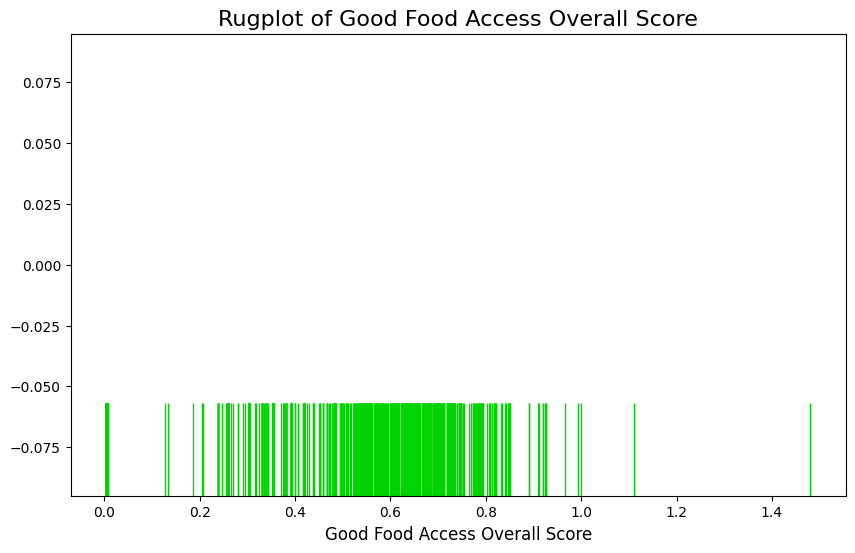

In [ ]:
# Just run this cell to generate a rugplot.
plt.figure(figsize=(10, 6))
sns.rugplot(merged_df['good_food_access_overall_score'], height=0.2, color='#00D400')
plt.title('Rugplot of Good Food Access Overall Score', fontsize=16)
plt.xlabel('Good Food Access Overall Score', fontsize=12)
plt.show()

### Question: How does seeing the data in a rugplot help you understand it differently than just looking at the numbers?

***Your Answer Here***

---

Note:
*   The data on food hubs are limited, so we're going narrow our focus to overall food access scores and the percent of native speakers for each nation

In [ ]:
simple_merged_df = merged_df.loc[:, ["Name", "AIANNHCE", "good_food_access_overall_score", "native_speakers_pct"]]

In [ ]:
simple_merged_df.head()

,Name,AIANNHCE,good_food_access_overall_score,native_speakers_pct
0,"Acoma Pueblo and Off-Reservation Trust Land, NM",10,0.316130,52.094
1,"Adais Caddo SDTSA, LA",9510,0.558801,0.000
2,Agua Caliente Indian Reservation and Off-Reser...,20,0.748721,0.456
3,"Akhiok ANVSA, AK",6015,0.678371,19.149
4,"Akiachak ANVSA, AK",6020,0.258417,84.572


---

Like we said earlier, a score that ranges from zero to two is a little bizarre. Just imagine how it'd be asking your friend how much they liked a movie and they said they'd give it 1.4 stars out of 2. You wouldn't know what they're talking about. So to avoid this problem happening with our data analysis, we're going to normalize the overall score. By normalizing it, the score is going to fall into the much mroe interpretable range of zero to one. This will be just like rating something zero to 100!

To select the data of a specific column you use **`DataFrame["column_name"]`**

In [ ]:
# Example:
df = pd.DataFrame({
    "animal": ["cat", "dog", "bird"],
    "weight_kg": [4.5, 22.7, 4],
    "height_cm": [25.0, 50.1, 100]
})
print("Example DataFrame.")
display(df)

print("\n The output after selecting the animal column.")
df["weight_kg"]

Example DataFrame.


,animal,weight_kg,height_cm
0,cat,4.5,25.0
1,dog,22.7,50.1
2,bird,4.0,100.0



 The output after selecting the animal column.


,weight_kg
0,4.5
1,22.7
2,4.0


You can store this data in a variable, like **`x`**, but you could name this variable anything as long as its name starts with a letter.

In [ ]:
# Example
z = df["weight_kg"]

In [ ]:
# Example
display(z)

,weight_kg
0,4.5
1,22.7
2,4.0


There are methods of math opertions you can use on columns, such as **`.min()`**, **`.mean()`**, **`.max()`**, and more.

In [ ]:
# Example
z.min()

4.0

You can also create new columns in a DataFrame by storing outputs to column selection for whatever you want to call that column
*   **`DataFrame["new_column_name"] = ...`**

In [ ]:
# Example
df["weight_lbs"] = df["weight_kg"] * 2.20462
display(df)

,animal,weight_kg,height_cm,weight_lbs
0,cat,4.5,25.0,9.920790
1,dog,22.7,50.1,50.044874
2,bird,4.0,100.0,8.818480


Your job is to normalize the **`good_food_access_overall_score`** column from the **`simple_merged_df`** DataFrame, then store it in **`simple_merged_df["normalized_score"]`**

The formula to normalize a numeric column is as follows:

<span style="font-size: 100%;">$\frac{x - \min(x)}{\max(x) - \min(x)}$</span>

Where x is the numeric column.

In [ ]:
# Normalize the overall score.

# Solution.
x = simple_merged_df["good_food_access_overall_score"]

answer = (x - x.min()) / (x.max() - x.min())

simple_merged_df["normalized_score"] = answer

In [ ]:
simple_merged_df.head()

,Name,AIANNHCE,good_food_access_overall_score,native_speakers_pct,normalized_score
0,"Acoma Pueblo and Off-Reservation Trust Land, NM",10,0.316130,52.094,0.211761
1,"Adais Caddo SDTSA, LA",9510,0.558801,0.000,0.375976
2,Agua Caliente Indian Reservation and Off-Reser...,20,0.748721,0.456,0.504495
3,"Akhiok ANVSA, AK",6015,0.678371,19.149,0.456889
4,"Akiachak ANVSA, AK",6020,0.258417,84.572,0.172707


Voila, we have added a normalized score to out DataFrame! Let's take a look at it visually with another rug plot to see if we accomplished what we set out to do.

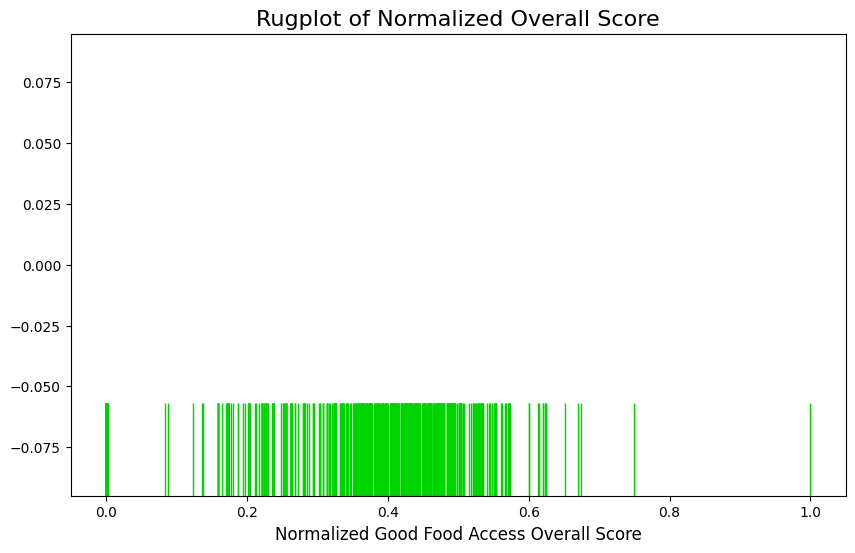

In [ ]:
plt.figure(figsize=(10, 6))
sns.rugplot(simple_merged_df['normalized_score'], height=0.2, color='#00D400')
plt.title('Rugplot of Normalized Overall Score', fontsize=16)
plt.xlabel('Normalized Good Food Access Overall Score', fontsize=12)
plt.show()

All of our values fall between zero and one, it was a success!

Now that we’ve normalized the scores, we can take a closer look at how they’re spread out. In the rug plot above, some areas have just a few lines, while others look almost solid. That’s because some scores appear more often than others. This is called density.

Density is how many data points show up near the same value. For example, there are a lot of scores around 0.4, but not many near 0.8. Rug plots show this, but not very clearly. To get a better picture, we’re going to add a KDE plot.
*   A KDE plot stands for Kernel Density Estimate plot. It’s a smooth curve that helps you see the shape of the data. With a KDE plot you can see where values are most common and where they aren't.

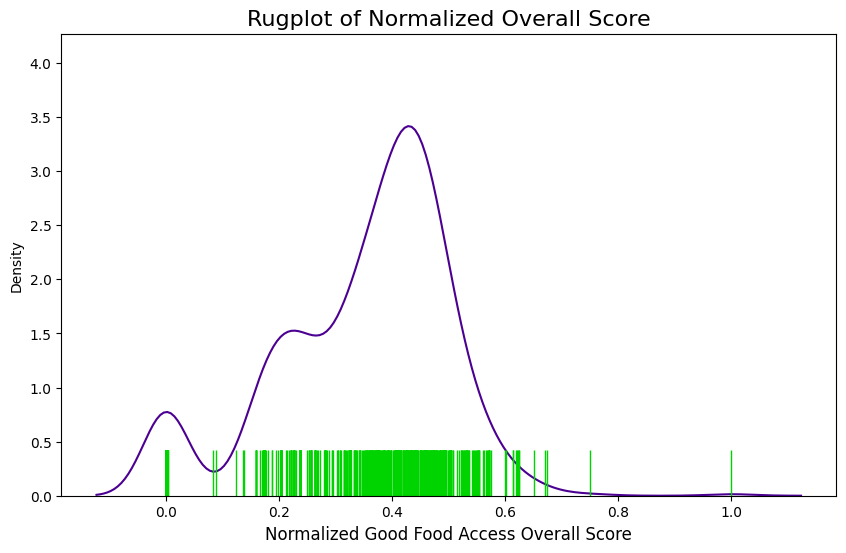

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(simple_merged_df['normalized_score'], color='#4B0092')
sns.rugplot(simple_merged_df['normalized_score'], height=0.1, color='#00D400')
plt.title('Rugplot of Normalized Overall Score', fontsize=16)
plt.xlabel('Normalized Good Food Access Overall Score', fontsize=12)
plt.show()

### Question: After looking at the KDE curve, what does it tell you about the distribution of food access among Native American communities?

***Your Answer Here***

### Question: If you had to describe the overall trend in food access using the KDE plot, how would you explain it in plain language?

***Your Answer Here***

### Question: How could this KDE plot be used to support food sovereignty efforts?

***Your Answer Here***

---

Now that we've taken a look at the KDE plot, which gives a smooth curve showing where values are most common, let's look at another common way to represent the same idea: a histogram.

Histograms break the data into chunks called bins. The height of each bar is the count of all the data that falls into that bin. It's kind of like sorting stuff into buckets, then seeing which buckets are empty and which are full.

A histogram is different than a KDE plot, because the histogram only smooths out the data, given how many bins it has.

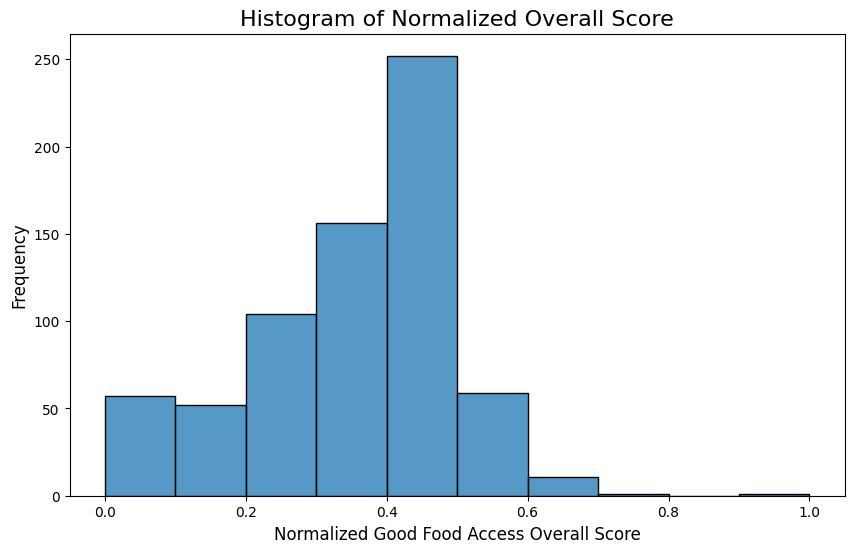

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(simple_merged_df['normalized_score'], bins=10)
plt.title('Histogram of Normalized Overall Score', fontsize=16)
plt.xlabel('Normalized Good Food Access Overall Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

### Question: What do you notice that's easier to see in the histogram? What do you think the KDE plot does better

***Your Answer Here***

---

We're going to shift our attention to comparing the distribution of high food access and the percentage of native language speakers.

In [ ]:
# Just run this cell.
simple_merged_df = simple_merged_df.loc[:, ["Name", "AIANNHCE", "normalized_score", "native_speakers_pct"]]
simple_merged_df.head()

,Name,AIANNHCE,normalized_score,native_speakers_pct
0,"Acoma Pueblo and Off-Reservation Trust Land, NM",10,0.211761,52.094
1,"Adais Caddo SDTSA, LA",9510,0.375976,0.000
2,Agua Caliente Indian Reservation and Off-Reser...,20,0.504495,0.456
3,"Akhiok ANVSA, AK",6015,0.456889,19.149
4,"Akiachak ANVSA, AK",6020,0.172707,84.572


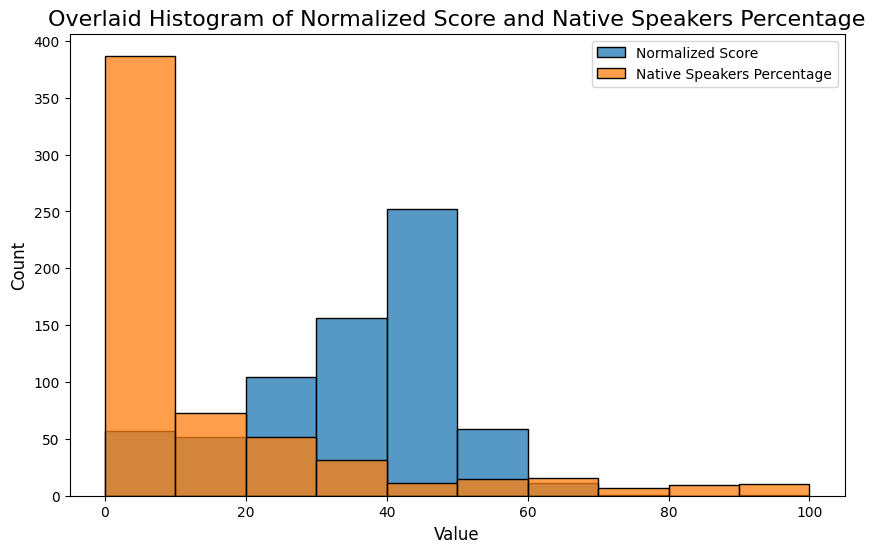

In [ ]:
# Just run this cell.
plt.figure(figsize=(10, 6))
sns.histplot(simple_merged_df['normalized_score']*100, bins=10, kde=False, label='Normalized Score')
sns.histplot(simple_merged_df['native_speakers_pct'], bins=10, kde=False, label='Native Speakers Percentage')
plt.title('Overlaid Histogram of Normalized Score and Native Speakers Percentage', fontsize=16)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.show()


This visualization shows that most Indigenous nations have fewer than 20% of their members speaking their cultural language. In fact, the most common situation is that fewer than 10% of people are native speakers. That means for many nations, only a small part of the community speaks the language at a fluent level.

### Question: Based onthis data, do you think high food access automatically leads to stronger cultural preservation? Why or why not?

***Your Answer Here***

### Question: What might the high values in the Native Speaker Percentage histogram represent? What do you imagine is happening in those communities?

***Your Answer Here***

Let's check out the 5 Indigenous territories with the highest percentage of native language speakers.

In [ ]:
# Just run this cell.
simple_merged_df.sort_values(by="native_speakers_pct", ascending=False).head(5)

,Name,AIANNHCE,normalized_score,native_speakers_pct
201,"Healy Lake ANVSA, AK",6575,0.281195,100.000
200,"Havasupai Reservation, AZ",1440,0.368935,100.000
75,"Chefornak ANVSA, AK",6275,0.172707,98.095
399,"Newtok ANVSA, AK",7055,0.172707,94.675
419,"Nunapitchuk ANVSA, AK",7135,0.172707,94.671


Note: ANVSA stands for Alaska Native Village Statistical Areas. ANVSAs may be permanent and/or seasonal residences for Indigenous Alaskans.

### Question: What attributes do these territories share? What might be influencing their high percentage of native speakers?

***Your Answer Here***

Now, let’s check out the community with the single highest percentage of native speakers

In [ ]:
# Just run this cell.
max_speakers_row = simple_merged_df.loc[simple_merged_df['native_speakers_pct'].idxmax()]
print(f"The territory with the highest percentage of native speakers is:\n{max_speakers_row}")

The territory with the highest percentage of native speakers is:
Name                   Havasupai Reservation, AZ
AIANNHCE                                    1440
normalized_score                        0.368935
native_speakers_pct                        100.0
Name: 200, dtype: object


The Havasupai Reservation is in a remote location in Arizona, inaccessible by car or truck (https://nptao.arizona.edu/havasupai-tribe).

### Question: How might the remoteness of the Havasupai Reservation help preserve the native language?

***Your Answer Here***

### Question: What are some possible advantages and challenges of living in a place that is difficult to access?
*   Hint: look back at the data.

***Your Answer Here***

---

# Conclusion

In this notebook, you've explored the Indigenous food sovereignty movement through data on crop diversity, food access, and Indigenous languages. You've learned some data science concepts and even did a little bit of coding. We encourage you to continue this journey, by thinking more about your relationship to food and the land it comes from and by carefully considering data that is presented to you, where it comes from and what might be missing from the story it is trying to tell you.

For Indigenous nations, food sovereignty is essential to self-determination. For those of us who are not Indigenous, listening to and supporting their efforts offers a model of living where health, culture, economy, and environment are not competing priorities. In a world facing climate crisis and a nation facing diet-related disease, Indigenous food sovereignty provides a magnifying glass with which to view the interconnectedness of our challenges and understand justice not as punishment for past wrongs, but as the creation of a fairer future.



---

### Attributions
This notebook was created by Alex Suggs and Areeya Tipyasothi, with help from Sanjana Sathish Kumar and Jraice Macer, as part of Data 4ac's collaboration with the UC Berkeley High School Ethnic Studies Initiative. UC Berkeley sits on Xučyun territory, the ancestral and unceded land of the Chochenyo Ohlone, from which we all benefit. We encourage those who may use this notebook to pay a Shuumi Land Tax to one of our main collaborators, [Sogorea Te' Land Trust ](https://sogoreate-landtrust.org/shuumi-land-tax/), or to make a contribution to an Indigenous organization more local to your area.